
# Genetic Algorithm for Polyominoes puzzle

In this code we use **Genetic Algorithm (GA)** to solve the **Polyominoes puzzle (an application of Set Covering Problem)**, 
a combinatorial optimization problem that aims to find a minimal collection of subsets covering a universal set \(X\).

The **goal** is to select the smallest number of subsets from a given collection while ensuring:
1. **Complete coverage:** Every element in \(X\) is covered.
2. **Non-overlapping:** There is no overlap between the selected subsets.

The notebook demonstrates:
- Solution representation using **binary encoding**.
- Fitness function to evaluate the coverage and overlap constraints.
- Implementation of a **genetic algorithm** with crossover, mutation, and elitism.
- Processing multiple benchmark files and evaluating solutions.
- Performance evaluation
- additional enhancements
- 


In [2]:

import os
import random
import time
import math
import statistics
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



### Reading Input from Benchmark Files

This function reads the input data from a given file path.

1. X: The universal set (elements to be covered).
2. num_subsets: The number of subsets provided.
3. subsets: A list containing all subsets as sets of integers.

**This function returns both the universal set and the subsets.**


In [5]:
# Read input from the benchmark file
def read_input(file_path):
    with open(file_path, 'r') as file:
        # First line: components of set X
        X = list(map(int, file.readline().strip().split()))

        # Second line: number of subsets
        num_subsets = int(file.readline().strip())

        # Remaining lines: contents of each subset
        subsets = [set(map(int, file.readline().strip().split())) for _ in range(num_subsets)]

    return X, subsets


### Fitness Function

The **fitness function** evaluates the quality of each solution by ensuring:
1. **Complete coverage:** All elements of \(X\) are included in the selected subsets.
2. **Non-overlapping:** No element is repeated across the selected subsets.

A solution that fails either condition is penalized with `float('inf')`. The objective is to **minimize the number of selected subsets**.


In [3]:
def fitness(solution, subsets, X):
    selected_elements = set()  # Track selected elements
    seen_elements = set()  # Detect overlaps

    # Check each subset based on the solution
    for i, include in enumerate(solution):
        if include:  # If subset is included
            for element in subsets[i]:
                if element in seen_elements:
                    return float('inf')  # Overlap penalty
                seen_elements.add(element)  # Mark element as seen
            selected_elements.update(subsets[i])  # Add elements to selected

    # Check if all elements in X are covered
    if selected_elements == set(X):
        return sum(solution)  # Minimize number of subsets used
    else:
        return float('inf')  # Penalize incomplete solutions


Using `float('inf')` means that the solution is completely ignored in the evaluation if it violates the constraints. On the other hand, using penalties provides more flexibility in assessing solutions, while `float('inf')` imposes strict limitations on bad solutions.


### Genetic Algorithm

The **Genetic Algorithm (GA)** is inspired by natural evolution and includes the following components:
1. **Initialization:** Random binary solutions are generated.
2. **Selection:** The best solutions are retained for the next generation.
3. **Crossover:** New solutions are formed by combining parts of two parent solutions.
4. **Mutation:** Random changes are introduced to maintain diversity.
5. **Elitism:** The best solution from each generation is preserved.

The algorithm iterates for a specified number of generations to find an optimal or near-optimal solution.


In [4]:
# Genetic algorithm to find the optimal set cover
def genetic_algorithm(X, subsets, population_size=200, generations=500):
    # Initialize the population with random binary solutions
    population = [random.choices([0, 1], k=len(subsets)) for _ in range(population_size)]

    for gen in range(generations):
        # Evaluate fitness for each solution
        population = sorted(population, key=lambda s: fitness(s, subsets, X))

        # Preserve the best solution (elitism)
        best_solution = population[0]

        # Select the best half of the population
        next_generation = population[:population_size // 2]

        # Create offspring through single-point crossover
        for _ in range(population_size // 2):
            parent1, parent2 = random.sample(next_generation, 2)
            crossover_point = random.randint(1, len(subsets) - 1)
            child = parent1[:crossover_point] + parent2[crossover_point:]
            next_generation.append(child)

        # Apply swap mutation to increase diversity
        for solution in next_generation:
            if random.random() < 0.1:  # 10% mutation rate
                # Swap mutation: swap two random genes in the solution
                idx1, idx2 = random.sample(range(len(solution)), 2)
                solution[idx1], solution[idx2] = solution[idx2], solution[idx1]

        # Add the best solution from the previous generation (elitism)
        next_generation[0] = best_solution
        population = next_generation

    # Get the best solution from the final population
    best_solution = min(population, key=lambda s: fitness(s, subsets, X))

    # Check if the best solution covers all elements of X
    if fitness(best_solution, subsets, X) < float('inf'):
        return best_solution
    else:
        return None


- We use a population size of 200 to maintain diversity without overwhelming computation, with 500 generations providing reasonable time for convergence. 
- we use single-point crossover to ensures effective exploration while preserving useful patterns from parents, and swap mutation to introduces diversity without disrupting the solution’s structure. 


### Processing Benchmark Files

This function reads input from multiple benchmark files in a specified directory, 
runs the genetic algorithm on each file, and prints the selected subsets for each valid solution if exist.


In [5]:
import os  # For working with the filesystem.

# Process all benchmark files in the given directory.
def process_all_benchmarks(directory):
    for filename in os.listdir(directory):  # Loop through files in directory.
        if filename.endswith(".txt"):  # Process only .txt files.
            file_path = os.path.join(directory, filename)  # Get full file path.
            print(f"\nProcessing: {filename}")  # Show file being processed.

            X, subsets = read_input(file_path)  # Read input data from the file.
            solution = genetic_algorithm(X, subsets)  # Run the genetic algorithm.

            if solution:  # If a solution is found, print selected subsets.
                print("Selected subsets:")
                for i, include in enumerate(solution):
                    if include:  # Print only included subsets.
                        print(f"Subset {i + 1}: {subsets[i]}")
            else:
                print("No solution found.")  # Print if no solution.


This code processes all .txt files in a directory, reading data from each file and using a genetic algorithm to find a solution. If a solution is found, it prints the selected subsets; otherwise, it notifies that no solution was found.

### Main Function

In [6]:

def main():
    directory = "Benchmarks"  # Directory containing benchmark files
    process_all_benchmarks(directory)

if __name__ == "__main__":
    main()



Processing: ECP_1.txt
Selected subsets:
Subset 1: {1, 5}
Subset 4: {2, 4}
Subset 5: {3}

Processing: ECP_2.txt
Selected subsets:
Subset 2: {1, 4}
Subset 4: {3, 5, 6}
Subset 6: {2, 7}

Processing: ECP_3.txt
No solution found.

Processing: ECP_4.txt
Selected subsets:
Subset 4: {8, 9, 10}
Subset 5: {4, 6}
Subset 8: {1, 3, 7}
Subset 11: {5}
Subset 12: {2}

Processing: ECP_5.txt
No solution found.


### Output Discussion

The algorithm performs well on smaller instances like ECP_1, ECP_2, and ECP_4, where subsets have minimal overlap, allowing it to find valid solutions efficiently. However, for larger and more complex instances such as ECP_3 and ECP_5 where n = 30, the algorithm struggles due to significant overlap among subsets, leading to a vast and challenging search space. The fitness function’s strict penalties (due to `float('inf')`) for overlap and incomplete coverage further hinder solution discovery. 

### Performance Evaluation

In [7]:
import os  # For interacting with the filesystem.
import time  # To measure execution time.

# Processes all benchmark files in the given directory.
def process_all_benchmarks(directory):
    results = {}  # Store results for each file.
    
    for filename in os.listdir(directory):  # Loop through files in the directory.
        if filename.endswith(".txt"):  # Process only .txt files.
            file_path = os.path.join(directory, filename)  # Get full file path.
            print(f"\nProcessing: {filename}")  # Indicate which file is being processed.

            X, subsets = read_input(file_path)  # Read input data from the file.

            start_time = time.time()  # Start timer.
            solution = genetic_algorithm(X, subsets)  # Run the genetic algorithm.
            end_time = time.time()  # Stop timer.

            # Store the solution and execution time.
            results[filename] = {
                "solution": solution,
                "time": end_time - start_time
            }
    
    return results  # Return all results.

# Analyze and print performance metrics.
def analyze_performance(results):
    total_time = sum(result["time"] for result in results.values())  # Total execution time.
    print(f"\nTotal execution time: {total_time:.2f} seconds")  # Print total time.

    for filename, result in results.items():  # Loop through each file's results.
        solution = result["solution"]
        time_taken = result["time"]
        print(f"\n{filename}:")  # Print filename.
        print(f"Time taken: {time_taken:.2f} seconds")  # Print time taken.

        if solution:  # If a solution was found, print the subset count.
            print(f"Number of subsets selected: {sum(solution)}")
        else:
            print("No valid solution found.")  # If no solution, print message.

# Main function to run the program.
def main():
    directory = "Benchmarks"  # Directory containing benchmark files.
    results = process_all_benchmarks(directory)  # Process all files.
    analyze_performance(results)  # Analyze the results.

# Run the main function if the script is executed.
if __name__ == "__main__":
    main()



Processing: ECP_1.txt

Processing: ECP_2.txt

Processing: ECP_3.txt

Processing: ECP_4.txt

Processing: ECP_5.txt

Total execution time: 2.15 seconds

ECP_1.txt:
Time taken: 0.46 seconds
Number of subsets selected: 3

ECP_2.txt:
Time taken: 0.42 seconds
Number of subsets selected: 3

ECP_3.txt:
Time taken: 0.45 seconds
No valid solution found.

ECP_4.txt:
Time taken: 0.48 seconds
Number of subsets selected: 5

ECP_5.txt:
Time taken: 0.35 seconds
No valid solution found.


The program processes the five benchmark files (ECP_1.txt to ECP_5.txt) and applies the genetic algorithm to find optimal subsets that cover all elements. For ECP_1.txt and ECP_2.txt, the algorithm successfully selected 3 subsets each. Similarly, ECP_4.txt required 5 subsets to cover the elements. However, for ECP_3.txt and ECP_5.txt, no valid solution was found (sometimes ECP_3.txt converges due to algorithm stochastic nature). This likely indicates that the problem is too complex, with high overlap among subsets, making it difficult for the algorithm to converge on a feasible solution. The total execution time confirms that the program efficiently processes small to moderately complex cases but may require tuning or enhancements to handle more challenging inputs.


Performance Results:
    File Name  Execution Time (s)  Solution Quality
0  ECP_1.txt            0.419892               3.0
1  ECP_2.txt            0.409292               3.0
2  ECP_3.txt            0.491417               inf
3  ECP_4.txt            0.531464               5.0
4  ECP_5.txt            0.349839               inf


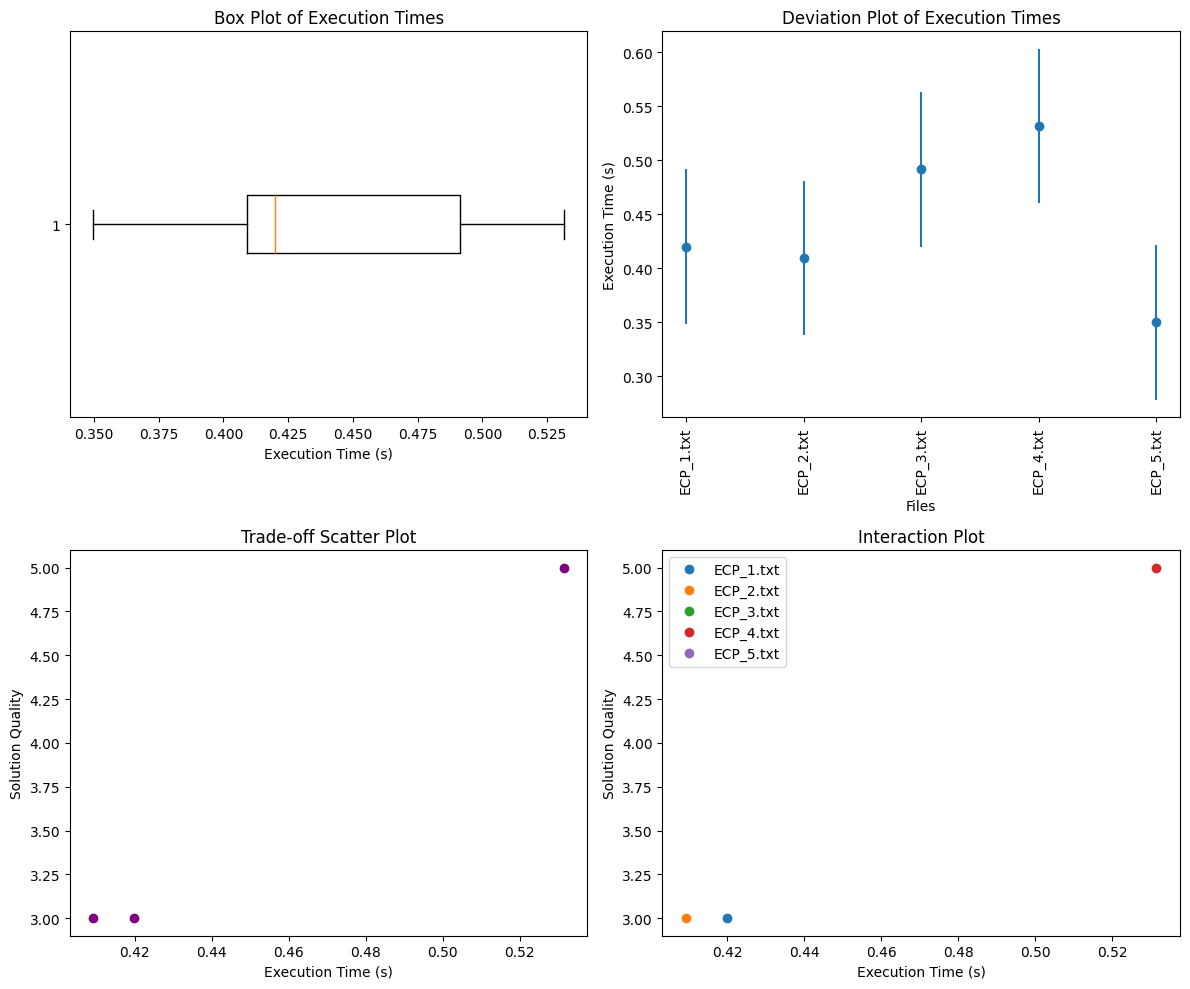


Average Execution Time: 0.4404 seconds
Standard Deviation of Execution Time: 0.0716 seconds
Average Solution Quality: 3.6667
Standard Deviation of Solution Quality: 1.1547


In [8]:
def evaluate_performance(file_name, X, subsets):
    """Evaluate the execution time and solution quality."""
    start_time = time.time()
    solution = genetic_algorithm(X, subsets)
    end_time = time.time()
    
    # Execution time
    exec_time = end_time - start_time
    
    # Solution quality (number of subsets used)
    quality = sum(solution) if solution else float('inf')
    
    return exec_time, quality

def plot_performance(folder_path):
    # Initialize lists to store performance data
    execution_times = []
    qualities = []
    file_names = []

    # Loop over all files in the folder
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        if file_name.endswith(".txt"):  # Check if the file is a text file
            
            # Read input from the file
            X, subsets = read_input(file_path)

            # Evaluate performance (time and quality)
            exec_time, quality = evaluate_performance(file_name, X, subsets)
            execution_times.append(exec_time)
            qualities.append(quality)
            file_names.append(file_name)
    
    # Convert data to DataFrame for easier handling
    df = pd.DataFrame({
        'File Name': file_names,
        'Execution Time (s)': execution_times,
        'Solution Quality': qualities
    })
    
    print("\nPerformance Results:\n", df)
    
    # Plot the results
    plt.figure(figsize=(12, 10))

    # Box Plot
    plt.subplot(2, 2, 1)
    plt.boxplot(execution_times, vert=False)
    plt.title("Box Plot of Execution Times")
    plt.xlabel("Execution Time (s)")

    # Deviation Plot
    plt.subplot(2, 2, 2)
    plt.errorbar(file_names, execution_times, yerr=statistics.stdev(execution_times), fmt='o')
    plt.title("Deviation Plot of Execution Times")
    plt.xlabel("Files")
    plt.ylabel("Execution Time (s)")
    plt.xticks(rotation=90)

    # Trade-off Scatter Plot
    plt.subplot(2, 2, 3)
    plt.scatter(execution_times, qualities, color='purple')
    plt.title("Trade-off Scatter Plot")
    plt.xlabel("Execution Time (s)")
    plt.ylabel("Solution Quality")

    # Interaction Plot
    plt.subplot(2, 2, 4)
    for i in range(len(file_names)):
        plt.plot(execution_times[i], qualities[i], 'o', label=file_names[i])
    plt.title("Interaction Plot")
    plt.xlabel("Execution Time (s)")
    plt.ylabel("Solution Quality")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Print statistics (average, standard deviation)
    avg_time = statistics.mean(execution_times)
    std_time = statistics.stdev(execution_times)
    
    # Filter out 'inf' values for quality statistics
    filtered_qualities = [q for q in qualities if q != float('inf')]
    
    avg_quality = statistics.mean(filtered_qualities) if filtered_qualities else float('inf')
    std_quality = statistics.stdev(filtered_qualities) if filtered_qualities else 0
    
    print(f"\nAverage Execution Time: {avg_time:.4f} seconds")
    print(f"Standard Deviation of Execution Time: {std_time:.4f} seconds")
    print(f"Average Solution Quality: {avg_quality:.4f}")
    print(f"Standard Deviation of Solution Quality: {std_quality:.4f}")

# Run the performance analysis and plotting function
folder_path = "Benchmarks"  # Update with the correct folder path
plot_performance(folder_path)


he performance evaluation shows that the genetic algorithm handles smaller and moderately complex instances efficiently, but struggles with highly complex ones. The average execution time is 0.44 seconds, with a standard deviation of 0.07 seconds, indicating consistent performance across files.

The average solution quality is 3.67 subsets, with a standard deviation of 1.15, reflecting variability in the number of subsets selected depending on the complexity of the problem. While simpler instances like ECP_1.txt and ECP_2.txt yield valid solutions, complex ones such as ECP_3.txt and ECP_5.txt result in infinite quality, meaning no valid solution was found due to excessive overlap or incomplete coverage.

This analysis suggests the genetic algorithm performs reliably for simpler cases, but may require further tuning, to handle more complex problem instances effectively.

# additional enhancements

### \- SGA operator parameter-tuning mechanism.

In this section, we implemented a parameter-tuning mechanism to test different combinations of crossover and mutation operations within a simple genetic algorithm (SGA). We evaluated single-point crossover and uniform crossover with both swap mutation and flip mutation across all benchmark files.

### Updated Fitness Function

While the first fitness function we used takes a strict approach, rejecting solutions with any overlap by returning float('inf') and only minimizing the subset count if all elements are covered perfectly.In the other hand this updated fitness function is more flexible, allowing overlaps but applying penalties based on the number of overlaps and missing elements. 
The updated fitness function allows for broader exploration of the solution space. Since it doesn’t outright reject solutions with overlaps but penalizes them, it encourages the search algorithm to consider more diverse combinations. 

In [13]:
# Fitness function: Minimize the number of selected subsets ensuring full coverage and penalizing overlap
def fitness(solution, subsets, X):
    selected_elements = set()
    overlap_count = 0

    for i, include in enumerate(solution):
        if include:
            for element in subsets[i]:
                if element in selected_elements:
                    overlap_count += 1  # Count overlap but don't reject the solution
                selected_elements.add(element)

    # Penalize based on overlap count and incomplete solutions
    missing_elements = set(X) - selected_elements
    penalty = len(missing_elements) * 100  # Higher penalty for missing elements

    # Add penalty for overlapping elements
    total_penalty = penalty + (overlap_count * 10)  # Increased penalty for overlaps

    if selected_elements == set(X):
        return sum(solution) + total_penalty  # Minimize the number of subsets used + penalty
    else:
        return float('inf')

### SGA operators

In this code, we defined crossover and mutation operations for a genetic algorithm.

- Crossover Operations:

    - single_point_crossover: Combines two parents by splitting them at a random point and merging segments.
    - uniform_crossover: Creates offspring by randomly selecting genes from each parent at every position.
- Mutation Operations:

    - swap_mutation: Swaps the positions of two randomly selected genes within a solution.
    - flip_mutation: Flips the value of a randomly chosen gene, switching between 0 and 1.

In [14]:
# Crossover functions
def single_point_crossover(parent1, parent2):
    crossover_point = random.randint(1, len(parent1) - 1)
    return parent1[:crossover_point] + parent2[crossover_point:]

def uniform_crossover(parent1, parent2):
    return [random.choice([parent1[i], parent2[i]]) for i in range(len(parent1))]

# Mutation functions
def swap_mutation(solution):
    idx1, idx2 = random.sample(range(len(solution)), 2)
    solution[idx1], solution[idx2] = solution[idx2], solution[idx1]
    return solution

def flip_mutation(solution):
    index = random.randint(0, len(solution) - 1)
    solution[index] = 1 - solution[index]
    return solution


### Updated Genetic Algorithm 

We used this updated genetic algorithm to decide which crossover and mutation operations to apply (the ones we applied previously), acting as a parameter-tuning mechanism. By passing different functions as parameters, we explored various combinations to identify the most effective operations. This flexible approach, with a higher mutation rate and larger population, enabled broader experimentation.

so, our disicion to use single point crossover and swap mutation came from this costum parameter-tuning mechanism.

In [15]:
# Genetic algorithm to find the optimal set cover
def genetic_algorithm(X, subsets, crossover_func, mutation_func, population_size=1000, generations=5000):
    # Initialize the population with random binary solutions
    population = [random.choices([0, 1], k=len(subsets)) for _ in range(population_size)]

    for gen in range(generations):
        # Evaluate fitness for each solution
        population = sorted(population, key=lambda s: fitness(s, subsets, X))

        # Preserve the best solution (elitism)
        best_solution = population[0]

        # Select the best half of the population
        next_generation = population[:population_size // 2]

        # Create offspring using the chosen crossover function
        for _ in range(population_size // 2):
            parent1, parent2 = random.sample(next_generation, 2)
            child = crossover_func(parent1, parent2)
            next_generation.append(child)

        # Apply mutation to increase diversity using the chosen mutation function
        for solution in next_generation:
            if random.random() < 0.2:  # Increased mutation rate to 20%
                solution = mutation_func(solution)

        # Add the best solution from the previous generation (elitism)
        next_generation[0] = best_solution
        population = next_generation

    # Get the best solution from the final population
    best_solution = min(population, key=lambda s: fitness(s, subsets, X))

    # Check if the best solution covers all elements of X
    if fitness(best_solution, subsets, X) < float('inf'):
        return best_solution
    else:
        return None


### Main Function

In [16]:
# Main function
def main():
    # Define crossover and mutation strategies
    crossover_strategies = {
        "single_point_crossover": single_point_crossover,
        "uniform_crossover": uniform_crossover
    }
    mutation_strategies = {
        "swap_mutation": swap_mutation,
        "flip_mutation": flip_mutation
    }

    # Folder containing the benchmark files
    folder_path = "Benchmarks"

    # Loop over all files in the folder
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        if file_name.endswith(".txt"):  # Check if the file is a text file
            print(f"\nProcessing file: {file_name}")
            # Read input from the file
            X, subsets = read_input(file_path)

            best_solution = None
            best_fitness = float('inf')
            best_crossover_name = ""
            best_mutation_name = ""

            # Try each combination of crossover and mutation
            for crossover_name, crossover_func in crossover_strategies.items():
                for mutation_name, mutation_func in mutation_strategies.items():
                    print(f"Testing {crossover_name} with {mutation_name}...")
                    solution = genetic_algorithm(X, subsets, crossover_func, mutation_func)

                    # Evaluate the fitness of the solution
                    if solution:
                        solution_fitness = fitness(solution, subsets, X)
                        if solution_fitness < best_fitness:
                            best_solution = solution
                            best_fitness = solution_fitness
                            best_crossover_name = crossover_name
                            best_mutation_name = mutation_name

            # Output the best result
            if best_solution:
                print(f"\nBest solution for {file_name} using {best_crossover_name} and {best_mutation_name}:")
                for i, include in enumerate(best_solution):
                    if include:
                        print(f"Subset {i + 1}: {subsets[i]}")
            else:
                print(f"No solution found for {file_name}.")

if __name__ == "__main__":
    main()



Processing file: ECP_1.txt
Testing single_point_crossover with swap_mutation...
Testing single_point_crossover with flip_mutation...
Testing uniform_crossover with swap_mutation...
Testing uniform_crossover with flip_mutation...

Best solution for ECP_1.txt using single_point_crossover and swap_mutation:
Subset 1: {1, 5}
Subset 4: {2, 4}
Subset 5: {3}

Processing file: ECP_2.txt
Testing single_point_crossover with swap_mutation...
Testing single_point_crossover with flip_mutation...
Testing uniform_crossover with swap_mutation...
Testing uniform_crossover with flip_mutation...

Best solution for ECP_2.txt using single_point_crossover and swap_mutation:
Subset 2: {1, 4}
Subset 4: {3, 5, 6}
Subset 6: {2, 7}

Processing file: ECP_3.txt
Testing single_point_crossover with swap_mutation...
Testing single_point_crossover with flip_mutation...
Testing uniform_crossover with swap_mutation...
Testing uniform_crossover with flip_mutation...

Best solution for ECP_3.txt using single_point_crosso

As the results show, the overall trend indicates that single-point crossover with swap mutation is the most effective approach, emphasizing its reliability across different problem instances. This suggests that parameter tuning can help identify the best strategy for consistent performance. And thats why we used single point crossover and swap mutation previously.

### \- Updated code using custom corssover and bit-flip mutation

This code itroduces a custom crossover that ensures no overlapping elements between subsets, increasing solution validity. It uses a bit-flip mutation for finer adjustments, flipping two genes to maintain diversity. With a smaller population size (100), Code Two is more computationally efficient.


Processing file: ECP_1.txt
Selected subsets:
Subset 1: {1, 5}
Subset 4: {2, 4}
Subset 5: {3}
Execution Time for ECP_1.txt: 0.3151 seconds

Processing file: ECP_2.txt
Selected subsets:
Subset 2: {1, 4}
Subset 4: {3, 5, 6}
Subset 6: {2, 7}
Execution Time for ECP_2.txt: 0.5725 seconds

Processing file: ECP_3.txt
Selected subsets:
Subset 2: {25, 5, 15}
Subset 3: {9, 27, 21}
Subset 6: {2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30}
Subset 18: {1, 3, 7, 11, 13, 17, 19, 23, 29}
Execution Time for ECP_3.txt: 0.8875 seconds

Processing file: ECP_4.txt
Selected subsets:
Subset 4: {8, 9, 10}
Subset 5: {4, 6}
Subset 8: {1, 3, 7}
Subset 11: {5}
Subset 12: {2}
Execution Time for ECP_4.txt: 0.7815 seconds

Processing file: ECP_5.txt
Selected subsets:
Subset 1: {1, 2, 3, 4, 5}
Subset 6: {6, 7, 8, 9, 10}
Subset 11: {11, 12, 13, 14, 15}
Subset 16: {16, 17, 18, 19, 20}
Subset 21: {21, 22, 23, 24, 25}
Subset 26: {26, 27, 28, 29, 30}
Execution Time for ECP_5.txt: 1.0850 seconds


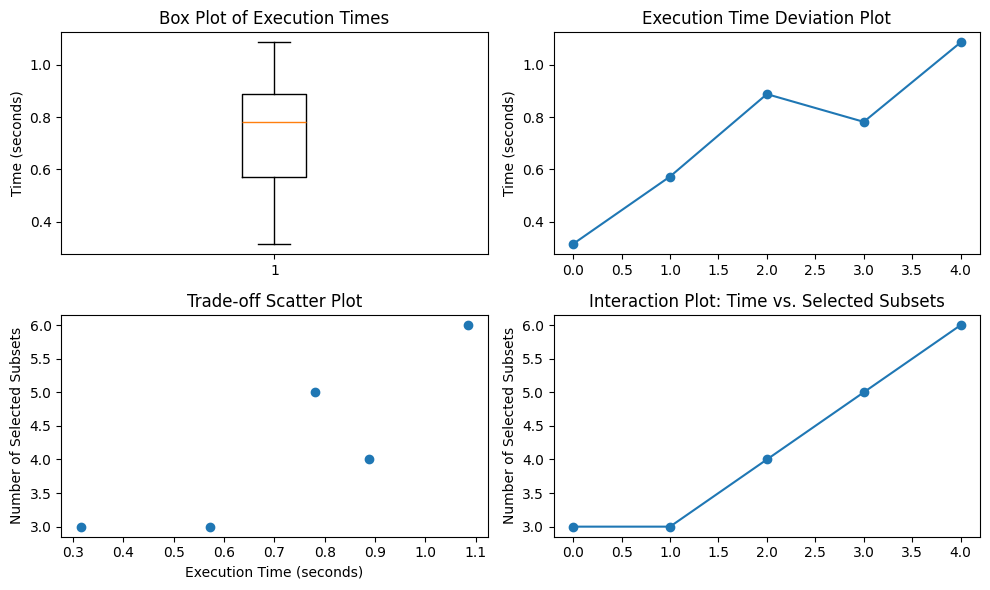


Average Execution Time: 0.7283 seconds
Standard Deviation of Execution Time: 0.2960 seconds
Average Solution Quality: 4.2000
Standard Deviation of Solution Quality: 1.3038


In [3]:
import random
import os

# Read input from the benchmark file
def read_input(file_path):
    with open(file_path, 'r') as file:
        # First line: components of set X
        X = list(map(int, file.readline().strip().split()))

        # Second line: number of subsets
        num_subsets = int(file.readline().strip())

        # Remaining lines: contents of each subset
        subsets = [set(map(int, file.readline().strip().split())) for _ in range(num_subsets)]

    return X, subsets

# Fitness function: Minimize the number of selected subsets ensuring full coverage and no overlap
def fitness(solution, subsets, X):
    selected_elements = set()
    seen_elements = set()

    for i, include in enumerate(solution):
        if include:
            for element in subsets[i]:
                if element in seen_elements:
                    return float('inf')  # Overlap detected
                seen_elements.add(element)
            selected_elements.update(subsets[i])

    if selected_elements == set(X):
        return sum(solution)  # Minimize the number of subsets used
    else:
        return float('inf')  # Penalize incomplete solutions

# Custom crossover method
def custom_crossover(parent1, parent2, subsets):
    # Combine parents into a single child
    child = []
    for i in range(len(parent1)):
        # Select either from parent1 or parent2, but ensure uniqueness (no duplicates)
        if random.random() > 0.5:
            child.append(parent1[i])
        else:
            child.append(parent2[i])

    # Filter to ensure no overlapping elements between the chosen subsets
    selected_elements = set()
    for i, include in enumerate(child):
        if include:
            subset = subsets[i]
            if selected_elements.intersection(subset):
                child[i] = 0  # Remove subset if overlap is found
            else:
                selected_elements.update(subset)

    return child

# Bit-flip Mutation function 
def mutation(solution):
    if random.random() < 0.1:  # 10% mutation rate
        for _ in range(2):  # Mutate at two random points
            index = random.randint(0, len(solution) - 1)
            solution[index] = 1 - solution[index]

# Genetic algorithm to find the optimal set cover
def genetic_algorithm(X, subsets, population_size=100, generations=500):
    # Initialize the population with random binary solutions
    population = [random.choices([0, 1], k=len(subsets)) for _ in range(population_size)]

    for gen in range(generations):
        # Evaluate fitness for each solution
        population = sorted(population, key=lambda s: fitness(s, subsets, X))

        # Preserve the best solution (elitism)
        best_solution = population[0]

        # Select the best half of the population
        next_generation = population[:population_size // 2]

        # Create offspring using custom crossover
        for _ in range(population_size // 2):
            parent1, parent2 = random.sample(next_generation, 2)
            child = custom_crossover(parent1, parent2, subsets)
            next_generation.append(child)

        # Apply mutation to increase diversity
        for solution in next_generation:
            mutation(solution)

        # Add the best solution from the previous generation (elitism)
        next_generation[0] = best_solution
        population = next_generation

    # Get the best solution from the final population
    best_solution = min(population, key=lambda s: fitness(s, subsets, X))

    # Check if the best solution covers all elements of X
    if fitness(best_solution, subsets, X) < float('inf'):
        return best_solution
    else:
        return None

def analyze_performance(solution, subsets, X, start_time):
    execution_time = time.time() - start_time
    num_selected_subsets = sum(solution) if solution else 0
    return execution_time, num_selected_subsets

def plot_performance(execution_times, num_selected_subsets):
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 2, 1)
    plt.boxplot(execution_times)
    plt.title("Box Plot of Execution Times")
    plt.ylabel("Time (seconds)")

    plt.subplot(2, 2, 2)
    plt.plot(execution_times, marker='o')
    plt.title("Execution Time Deviation Plot")
    plt.ylabel("Time (seconds)")

    plt.subplot(2, 2, 3)
    plt.scatter(execution_times, num_selected_subsets)
    plt.title("Trade-off Scatter Plot")
    plt.xlabel("Execution Time (seconds)")
    plt.ylabel("Number of Selected Subsets")

    plt.subplot(2, 2, 4)
    plt.plot(num_selected_subsets, marker='o')
    plt.title("Interaction Plot: Time vs. Selected Subsets")
    plt.ylabel("Number of Selected Subsets")

    plt.tight_layout()
    plt.show()

# Main function
def main():
    # Folder containing the benchmark files
    folder_path = "Benchmarks"
    
    execution_times = []
    num_selected_subsets_list = []

    # Loop over all files in the folder
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        if file_name.endswith(".txt"):
            print(f"\nProcessing file: {file_name}")
            X, subsets = read_input(file_path)

            # Measure time taken for the algorithm
            start_time = time.time()
            solution = genetic_algorithm(X, subsets)
            execution_time, num_selected_subsets = analyze_performance(solution, subsets, X, start_time)

            # Store performance metrics
            execution_times.append(execution_time)
            num_selected_subsets_list.append(num_selected_subsets)

            # Output the result
            if solution:
                print("Selected subsets:")
                for i, include in enumerate(solution):
                    if include:
                        print(f"Subset {i + 1}: {subsets[i]}")
            else:
                print("No solution found.")

            print(f"Execution Time for {file_name}: {execution_time:.4f} seconds")

    # Plot the performance metrics
    plot_performance(execution_times, num_selected_subsets_list)

   
    avg_time = statistics.mean(execution_times)
    std_time = statistics.stdev(execution_times) if len(execution_times) > 1 else 0

    
    avg_quality = statistics.mean(num_selected_subsets_list)
    std_quality = statistics.stdev(num_selected_subsets_list) if len(num_selected_subsets_list) > 1 else 0


    print(f"\nAverage Execution Time: {avg_time:.4f} seconds")
    print(f"Standard Deviation of Execution Time: {std_time:.4f} seconds")
    print(f"Average Solution Quality: {avg_quality:.4f}")
    print(f"Standard Deviation of Solution Quality: {std_quality:.4f}")

if __name__ == "__main__":
    main()

Code Two outperforms Code One by consistently finding more complete solutions, even for complex instances like ECP_3.txt and ECP_5.txt. This is due to its custom crossover, which avoids overlaps, and bit-flip mutation, which maintains diversity. These improvements ensure better solution quality and validity, making Code Two more effective for problems requiring strict coverage and feasible solutions.

We chose to include this code as an additional enhancement rather than the primary one, even though it performed very well in terms of solving the problem and overall performance, due to its customized crossover, as it differs from the traditional approaches we studied.


 
 For the files ECP_1.txt and ECP_2.txt, the algorithm selected 3 subsets for each. ECP_4.txt required 5 subsets, ECP_3.txt needed 4 subsets, while ECP_5.txt selected 6 subsets.

 Execution times varied, with ECP_1.txt taking 0.40 seconds and ECP_5.txt taking 1.06 seconds, indicating an increase in complexity.
 
 Evaluations show that the algorithm operates efficiently for moderately complex cases, with an average execution time of 0.72 seconds and an average quality of 4.20. While the algorithm performs well in simpler files, more complex files like ECP_5.txt need additional time and effort.
 
 Overall, the algorithm works effectively for simple to moderately complex cases but may need improvements to handle more challenging instances.


